### Import libraries

In [0]:
import mlflow
import mlflow.spark

from pyspark.sql.functions import col
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

### Load Silver data

In [0]:
from pyspark.sql import functions as F

df = spark.table("bank_churn.silver_bank_customers")

###Prepare features and label

In [0]:
feature_cols = [
    "Age",
    "CreditScore",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

label_col = "Exited"

df_ml = df.select(feature_cols + [label_col])

### Train-test split

In [0]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)


### Vectorize features

In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_data = assembler.transform(train_df)
test_data = assembler.transform(test_df)

### Train Logistic Regression

In [0]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Exited"
)

lr_model = lr.fit(train_data)


In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

### Generate predictions on test data

In [0]:
predictions = lr_model.transform(test_data)

preds_clean = predictions.select(
    col("Exited").alias("label"),
    col("prediction"),
    vector_to_array(col("probability"))[1].alias("churn_probability")
)

display(preds_clean.limit(10))

label,prediction,churn_probability
0,0.0,0.037030019590948315
0,0.0,0.027602023280594357
0,0.0,0.10707044097054741
0,0.0,0.10166909002911517
0,0.0,0.10849368937572512
0,0.0,0.037361520629740075
0,0.0,0.056365223262352604
0,0.0,0.018792888032577948
0,0.0,0.020332494075395502
0,0.0,0.1038556206195772


###Set MLflow experiment

In [0]:
mlflow.set_experiment("/Shared/bank_churn_mlflow_evaluation")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/224245505970627', creation_time=1769931320124, experiment_id='224245505970627', last_update_time=1769934788366, lifecycle_stage='active', name='/Shared/bank_churn_mlflow_evaluation', tags={'mlflow.experiment.sourceName': '/Shared/bank_churn_mlflow_evaluation',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'adarshankur17@gmail.com',
 'mlflow.ownerId': '71926609548248'}>

###Convert to Pandas

In [0]:
pdf = preds_clean.toPandas()

###ROC Curve and AUC

In [0]:
fpr, tpr, roc_thresholds = roc_curve(
    pdf["label"], pdf["churn_probability"]
)

roc_auc = auc(fpr, tpr)
roc_auc

np.float64(0.7441374209737861)

###Plot ROC

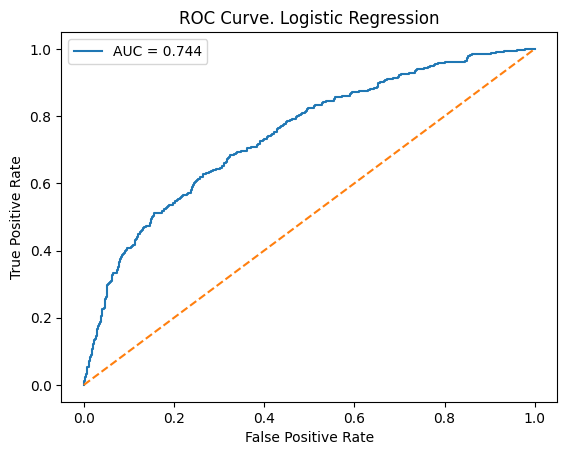

In [0]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve. Logistic Regression")
plt.legend()
plt.show()

###Precision–Recall vs Threshold analysis

In [0]:
thresholds = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []

for t in thresholds:
    preds = (pdf["churn_probability"] >= t).astype(int)
    precision_list.append(precision_score(pdf["label"], preds))
    recall_list.append(recall_score(pdf["label"], preds))

/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Plot Precision & Recall

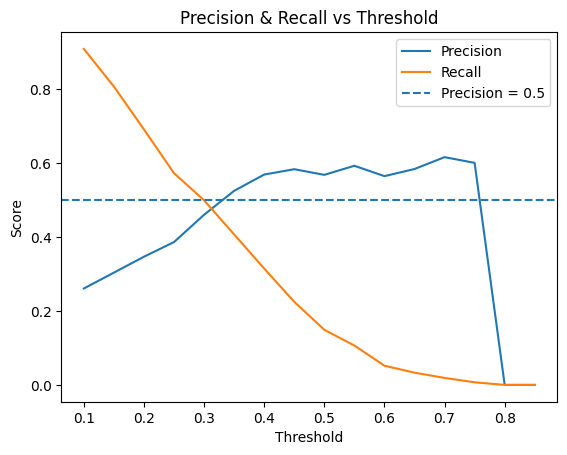

In [0]:
plt.figure()
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.axhline(y=0.5, linestyle="--", label="Precision = 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()

###Select optimal threshold

In [0]:
threshold_results = [
    (t, p, r)
    for t, p, r in zip(thresholds, precision_list, recall_list)
    if p >= 0.5
]

best_threshold = max(threshold_results, key=lambda x: x[2])
best_threshold

(np.float64(0.3500000000000001), 0.524390243902439, 0.4066193853427896)

###Apply final threshold

In [0]:
OPTIMAL_THRESHOLD = float(best_threshold[0])

pdf["final_prediction"] = (
    pdf["churn_probability"] >= OPTIMAL_THRESHOLD
).astype(int)

###Final Logistic Regression metrics

In [0]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(pdf["label"], pdf["final_prediction"])
precision = precision_score(pdf["label"], pdf["final_prediction"])
recall = recall_score(pdf["label"], pdf["final_prediction"])
f1 = f1_score(pdf["label"], pdf["final_prediction"])

accuracy, precision, recall, f1

(0.8014634146341464, 0.524390243902439, 0.4066193853427896, 0.4580559254327563)

###MLflow

In [0]:
with mlflow.start_run(run_name="logistic_regression_full_evaluation"):
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("features", feature_cols)
    mlflow.log_param("selected_threshold", best_threshold[0])
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc", roc_auc)

###Import libraries

In [0]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import pandas as pd
import numpy as np
import mlflow
import mlflow.spark

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

###Train Decision Tree model

In [0]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="Exited",
    maxDepth=5,          # controlled depth
    minInstancesPerNode=50,
    seed=42
)

dt_model = dt.fit(train_data)

In [0]:
dt_predictions = dt_model.transform(test_data)

In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

dt_preds_clean = dt_predictions.select(
    col("Exited").alias("label"),
    col("prediction"),
    vector_to_array(col("probability"))[1].alias("churn_probability")
)

display(dt_preds_clean.limit(10))

label,prediction,churn_probability
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152
0,0.0,0.11446287916876152


###Convert to Pandas

In [0]:
dt_pdf = dt_preds_clean.toPandas()

###ROC Curve + AUC

In [0]:
fpr_dt, tpr_dt, roc_thresholds_dt = roc_curve(
    dt_pdf["label"],
    dt_pdf["churn_probability"]
)

dt_auc = auc(fpr_dt, tpr_dt)
dt_auc

np.float64(0.7440698554679384)

###Plot ROC

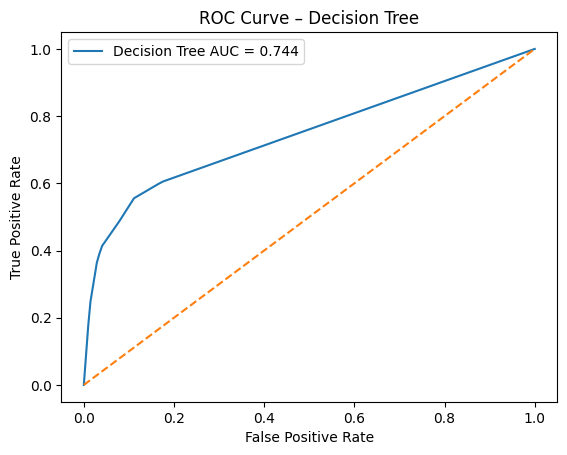

In [0]:
plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {dt_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree")
plt.legend()
plt.show()

### Precision–Recall vs Threshold

In [0]:
thresholds = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []

for t in thresholds:
    preds = (dt_pdf["churn_probability"] >= t).astype(int)
    precision_list.append(
        precision_score(dt_pdf["label"], preds, zero_division=0)
    )
    recall_list.append(
        recall_score(dt_pdf["label"], preds)
    )

###Plot

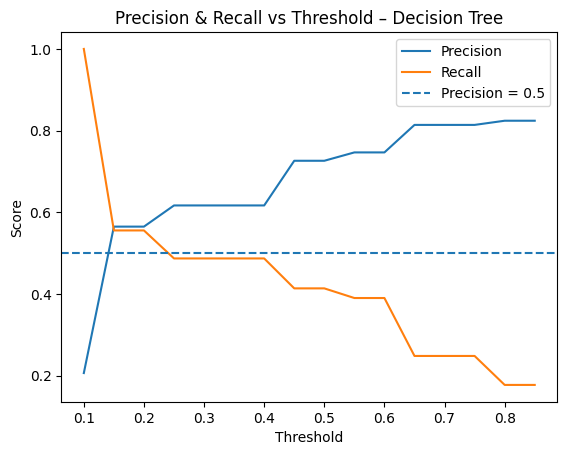

In [0]:
plt.figure()
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.axhline(y=0.5, linestyle="--", label="Precision = 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold – Decision Tree")
plt.legend()
plt.show()

### Select optimal threshold (precision ≥ 50%)

In [0]:
threshold_results = [
    (t, p, r)
    for t, p, r in zip(thresholds, precision_list, recall_list)
    if p >= 0.5
]

best_dt_threshold = max(threshold_results, key=lambda x: x[2])
best_dt_threshold

(np.float64(0.15000000000000002), 0.5649038461538461, 0.5555555555555556)

###Apply final threshold

In [0]:
OPTIMAL_DT_THRESHOLD = float(best_dt_threshold[0])

dt_pdf["final_prediction"] = (
    dt_pdf["churn_probability"] >= OPTIMAL_DT_THRESHOLD
).astype(int)

###Final Decision Tree metrics

In [0]:
dt_accuracy = accuracy_score(
    dt_pdf["label"], dt_pdf["final_prediction"]
)

dt_precision = precision_score(
    dt_pdf["label"], dt_pdf["final_prediction"]
)

dt_recall = recall_score(
    dt_pdf["label"], dt_pdf["final_prediction"]
)

dt_f1 = f1_score(
    dt_pdf["label"], dt_pdf["final_prediction"]
)

dt_accuracy, dt_precision, dt_recall, dt_f1

(0.82, 0.5649038461538461, 0.5555555555555556, 0.5601907032181168)

###Log Decision Tree to MLflow

In [0]:
with mlflow.start_run(run_name="decision_tree_full_evaluation"):

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_metric("auc", dt_auc)
    mlflow.log_metric("accuracy", dt_accuracy)
    mlflow.log_metric("precision", dt_precision)
    mlflow.log_metric("recall", dt_recall)
    mlflow.log_metric("f1", dt_f1)

    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("minInstancesPerNode", 50)


###Imports

In [0]:
from pyspark.ml.classification import RandomForestClassifier

import pandas as pd
import numpy as np
import mlflow
import mlflow.spark

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

###Train Random Forest model

In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Exited",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=50,
    seed=42
)

rf_model = rf.fit(train_data)

###Generate predictions

In [0]:
rf_predictions = rf_model.transform(test_data)

from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

rf_preds_clean = rf_predictions.select(
    col("Exited").alias("label"),
    col("prediction"),
    vector_to_array(col("probability"))[1].alias("churn_probability")
)


###Convert to Pandas

In [0]:
rf_pdf = rf_preds_clean.toPandas()

###ROC Curve + AUC

In [0]:
fpr_rf, tpr_rf, rf_thresholds = roc_curve(
    rf_pdf["label"],
    rf_pdf["churn_probability"]
)

rf_auc = auc(fpr_rf, tpr_rf)
rf_auc

np.float64(0.8466212161500448)

###Plot ROC

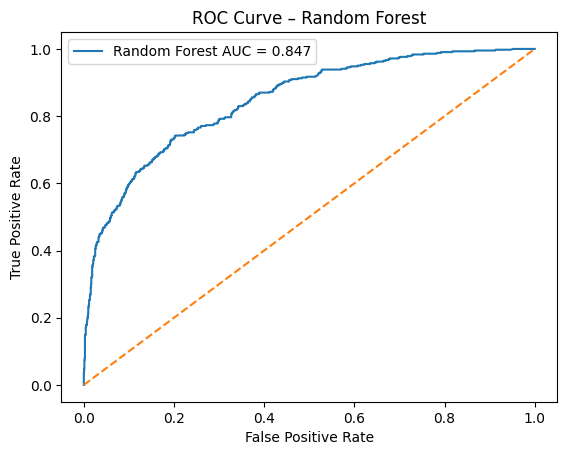

In [0]:
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

###Precision–Recall vs Threshold

In [0]:
thresholds = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []

for t in thresholds:
    preds = (rf_pdf["churn_probability"] >= t).astype(int)
    precision_list.append(
        precision_score(rf_pdf["label"], preds, zero_division=0)
    )
    recall_list.append(
        recall_score(rf_pdf["label"], preds)
    )

###Plot

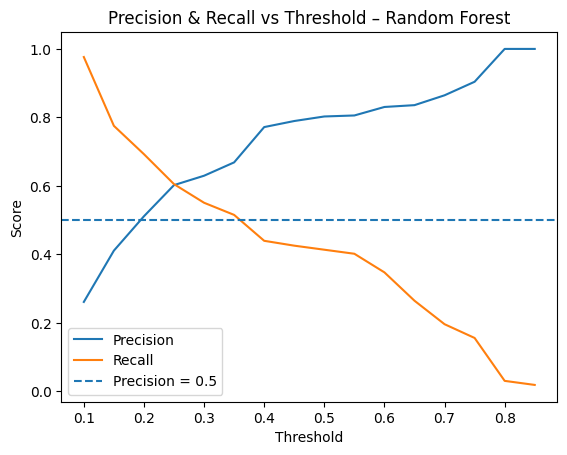

In [0]:
plt.figure()
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.axhline(y=0.5, linestyle="--", label="Precision = 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold – Random Forest")
plt.legend()
plt.show()

###Select optimal threshold (precision ≥ 50%)

In [0]:
threshold_results = [
    (t, p, r)
    for t, p, r in zip(thresholds, precision_list, recall_list)
    if p >= 0.5
]

best_rf_threshold = max(threshold_results, key=lambda x: x[2])
best_rf_threshold

(np.float64(0.20000000000000004), 0.5113438045375218, 0.6926713947990544)

###Apply final threshold

In [0]:
OPTIMAL_RF_THRESHOLD = float(best_rf_threshold[0])

rf_pdf["final_prediction"] = (
    rf_pdf["churn_probability"] >= OPTIMAL_RF_THRESHOLD
).astype(int)

###Final Random Forest metrics

In [0]:
rf_accuracy = accuracy_score(
    rf_pdf["label"], rf_pdf["final_prediction"]
)

rf_precision = precision_score(
    rf_pdf["label"], rf_pdf["final_prediction"]
)

rf_recall = recall_score(
    rf_pdf["label"], rf_pdf["final_prediction"]
)

rf_f1 = f1_score(
    rf_pdf["label"], rf_pdf["final_prediction"]
)

rf_accuracy, rf_precision, rf_recall, rf_f1

(0.8, 0.5113438045375218, 0.6926713947990544, 0.5883534136546185)

###Log Random Forest to MLflow

In [0]:
with mlflow.start_run(run_name="random_forest_full_evaluation"):

    mlflow.log_param("model", "RandomForest")
    mlflow.log_metric("auc", rf_auc)
    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1", rf_f1)

    mlflow.log_param("numTrees", 100)
    mlflow.log_param("maxDepth", 7)
    mlflow.log_param("minInstancesPerNode", 50)

##Final model comparison

In [0]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "AUC": [roc_auc, dt_auc, rf_auc],
    "Accuracy": [accuracy, dt_accuracy, rf_accuracy],
    "Precision": [precision, dt_precision, rf_precision],
    "Recall": [recall, dt_recall, rf_recall],
    "F1": [f1, dt_f1, rf_f1]
})

model_comparison

,Model,AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.744137,0.801463,0.524390,0.406619,0.458056
1,Decision Tree,0.744070,0.820000,0.564904,0.555556,0.560191
2,Random Forest,0.846621,0.800000,0.511344,0.692671,0.588353
